[데이터 확인 중...] 캐글에서 경로를 가져옵니다.


100%|██████████| 682M/682M [00:17<00:00, 41.0MB/s]

Extracting files...


다운로드 경로: /root/.cache/kagglehub/datasets/prondeau/the-car-connection-picture-dataset/versions/1

폴더 내 전체 이미지 수: 64467장

=== 파일명 파싱 매칭 테스트 (상위 5개) ===
원본 파일명: Chevrolet_Silverado 2500HD_2016_53_20_360_60_8_80_78_nan_nan_RWD_5_4_Pickup_AaO.jpg
👉 추출된 브랜드명(라벨): Chevrolet
--------------------------------------------------
원본 파일명: Hyundai_Sonata_2011_27_18_270_20_4_72_57_189_22_FWD_5_4_4dr_IvW.jpg
👉 추출된 브랜드명(라벨): Hyundai
--------------------------------------------------
원본 파일명: Kia_K900_2016_54_18_310_38_6_74_58_200_17_RWD_5_4_4dr_nlU.jpg
👉 추출된 브랜드명(라벨): Kia
--------------------------------------------------
원본 파일명: Audi_A4_2015_37_17_220_20_4_71_56_185_22_AWD_5_4_4dr_dym.jpg
👉 추출된 브랜드명(라벨): Audi
--------------------------------------------------
원본 파일명: Acura_MDX_2019_44_18_290_35_6_77_67_196_20_FWD_7_4_SUV_njJ.jpg
👉 추출된 브랜드명(라벨): Acura
--------------------------------------------------

[시각화 검증] 실제 이미지와 파싱된 브랜드명이 일치하는지 확인합니다...


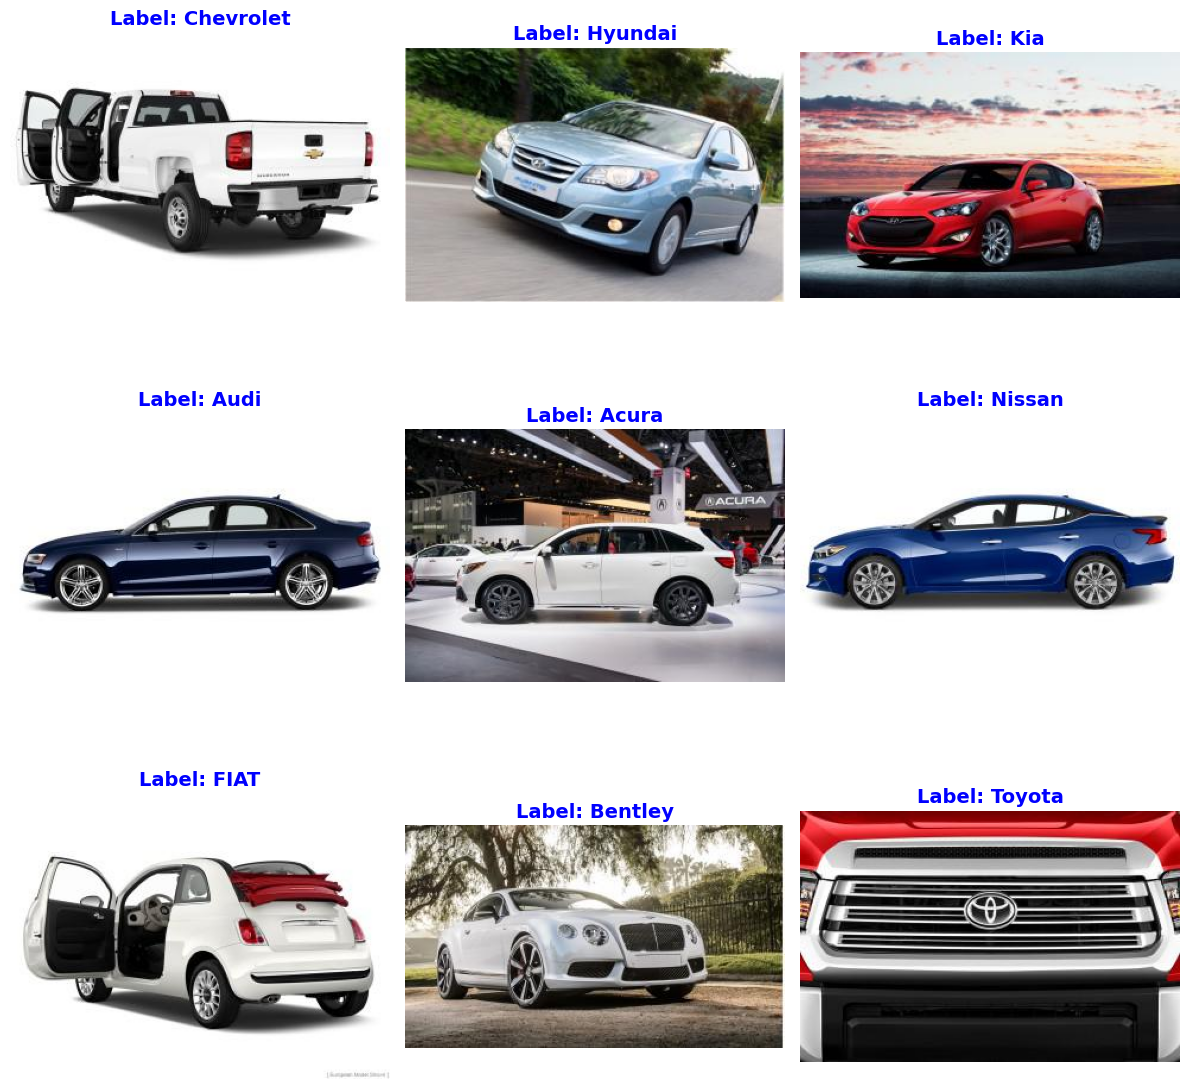

In [1]:
import os
import kagglehub
import matplotlib.pyplot as plt
import cv2 # 이미지 로드용 빌트인 라이브러리

# 1. 캐글 데이터셋 경로 가져오기
print("[데이터 확인 중...] 캐글에서 경로를 가져옵니다.")
path = kagglehub.dataset_download("prondeau/the-car-connection-picture-dataset")
print(f"다운로드 경로: {path}\n")

# 2. 이미지 파일만 필터링
valid_extensions = ('.jpg', '.jpeg', '.png')
all_files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]
print(f"폴더 내 전체 이미지 수: {len(all_files)}장\n")

# 3. 상위 5개 파일명 파싱 결과 출력 (로그 확인)
print("=== 파일명 파싱 매칭 테스트 (상위 5개) ===")
for i, file_name in enumerate(all_files[:5]):
    brand = file_name.split('_')[0]
    print(f"원본 파일명: {file_name}")
    print(f"👉 추출된 브랜드명(라벨): {brand}")
    print("-" * 50)

# 4. 실제로 파싱한 브랜드명이 맞는지 이미지 직접 시각화 (9개 샘플)
print("\n[시각화 검증] 실제 이미지와 파싱된 브랜드명이 일치하는지 확인합니다...")
plt.figure(figsize=(12, 12))

for i in range(min(9, len(all_files))):
    file_name = all_files[i]
    brand = file_name.split('_')[0] # 언더바 기준으로 브랜드 추출

    # 이미지 읽기 및 BGR에서 RGB로 변환
    img_path = os.path.join(path, file_name)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 그리기
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {brand}", fontsize=14, color="blue", weight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
import os
import kagglehub
from collections import Counter

# 1. 데이터셋 경로 설정
path = kagglehub.dataset_download("prondeau/the-car-connection-picture-dataset")

# 2. 이미지 파일만 리스트업
valid_extensions = ('.jpg', '.jpeg', '.png')
all_files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]

# 3. 전체 파일에서 브랜드명만 추출하여 리스트에 담기
all_brands = []
for file_name in all_files:
    brand = file_name.split('_')[0]
    all_brands.append(brand)

# 4. 통계 계산 (빈도수 측정)
brand_counts = Counter(all_brands)
unique_brands = sorted(list(brand_counts.keys())) # 알파벳 순 정렬

# 5. 결과 출력
print(f"▶ 데이터셋 내 총 고유 브랜드 수: {len(unique_brands)}개")
print("=" * 50)
print(f"{'브랜드명':<18} | {'보유 사진 수':<10}")
print("-" * 50)

for brand in unique_brands:
    print(f"{brand:<20} | {brand_counts[brand]:>6}장")

print("=" * 50)

▶ 데이터셋 내 총 고유 브랜드 수: 42개
브랜드명               | 보유 사진 수   
--------------------------------------------------
Acura                |   1174장
Alfa Romeo           |    290장
Aston Martin         |    574장
Audi                 |   3131장
BMW                  |   4121장
Bentley              |    697장
Buick                |    964장
Cadillac             |   1311장
Chevrolet            |   5079장
Chrysler             |    570장
Dodge                |   1345장
FIAT                 |    892장
Ferrari              |     91장
Ford                 |   4416장
GMC                  |   2067장
Genesis              |    176장
Honda                |   2675장
Hyundai              |   2091장
INFINITI             |    917장
Jaguar               |   1062장
Jeep                 |   1196장
Kia                  |   2160장
Lamborghini          |    251장
Land Rover           |    960장
Lexus                |   2125장
Lincoln              |   1324장
MINI                 |   1059장
Maserati             |    449장
Mazda                |  

In [3]:
import tensorflow as tf
print("사용 가능한 GPU 목록:", tf.config.list_physical_devices('GPU'))

사용 가능한 GPU 목록: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub

# ── [1단계] 데이터 다운로드 ──────────────────────────────────────────
print("[데이터 다운로드 중...] 캐글에서 이미지를 가져옵니다.")
path = kagglehub.dataset_download("prondeau/the-car-connection-picture-dataset")
print(f"다운로드 완료 경로: {path}")

valid_extensions = ('.jpg', '.jpeg', '.png')
all_files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]
print(f"디스크 내 전체 이미지 수: {len(all_files)}장")

# ── [2단계] 상위 10개 타겟 브랜드 필터링 ──────────────────────────────
target_brands = ['Hyundai', 'Kia', 'Toyota', 'Honda', 'Lexus', 'Nissan', 'BMW', 'Audi', 'Mercedes-Benz', 'Chevrolet']

file_paths = []
brands = []

for file_name in all_files:
    brand = file_name.split('_')[0]
    if brand in target_brands:
        file_paths.append(os.path.join(path, file_name))
        brands.append(brand)

# 정수 인덱스 라벨 매핑 (0 ~ 9번 순차 인덱싱)
class_names = sorted(list(set(brands)))
num_classes = len(class_names)
brand_to_idx = {name: idx for idx, name in enumerate(class_names)}
labels = [brand_to_idx[b] for b in brands]

print(f"\n▶ 필터링 완료된 타겟 브랜드 수: {num_classes}개")
print(f"▶ 학습에 사용될 총 이미지 수: {len(file_paths)}장")
print(f"▶ 브랜드별 매핑 인덱스: {brand_to_idx}")

# ── [3단계] 데이터 셔플 및 분할 (Train 70% / Val 15% / Test 15%) ──
file_paths = np.array(file_paths)
labels = np.array(labels)

np.random.seed(42)
indices = np.arange(len(file_paths))
np.random.shuffle(indices)

file_paths = file_paths[indices]
labels = labels[indices]

total_count = len(file_paths)
train_end = int(total_count * 0.7)
val_end = int(total_count * 0.85)

train_paths, train_labels = file_paths[:train_end], labels[:train_end]
val_paths, val_labels     = file_paths[train_end:val_end], labels[train_end:val_end]
test_paths, test_labels   = file_paths[val_end:], labels[val_end:]

# ── [4단계] 이미지 텐서 파싱 함수 정의 (고속 디코딩 및 가형태 고정) ──
img_size = (224, 224)

def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    # decode_image가 decode_jpeg보다 내부 컴파일 최적화에 유리합니다.
    image = tf.image.decode_image(image_string, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size)
    # [핵심] 텐서 셰이프를 명시적으로 고정해야 배치 묶는 속도(Batching)가 빨라집니다.
    image.set_shape((224, 224, 3))
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
# GPU 연산 유닛이 쉴 틈 없이 일하도록 배치 사이즈를 128로 상향 조정합니다.
batch_size = 128

# deterministic=False로 설정하여 디스크에서 먼저 읽히는 파일부터 순서 상관없이 처리(속도 극대화)
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)) \
    .map(parse_image, num_parallel_calls=AUTOTUNE, deterministic=False)

val_ds   = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)) \
    .map(parse_image, num_parallel_calls=AUTOTUNE)

test_ds  = tf.data.Dataset.from_tensor_slices((test_paths, test_labels)) \
    .map(parse_image, num_parallel_calls=AUTOTUNE)

# ── [5단계] 데이터 증강 및 멀티스레드 프리페치(Prefetch) 버퍼 최적화 ──
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

# 증강 기능도 병렬화된 CPU 자원을 활용하여 선연산 처리합니다.
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

# 셔플 버퍼를 확보하고 배치를 묶은 뒤, GPU가 연산할 동안 CPU가 다음 배치를 미리 메모리에 쟁여놓도록 만듭니다.
train_ds = train_ds.shuffle(buffer_size=2000).batch(batch_size).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

# ── [6단계] 불균형 보정용 Class Weight 계산 ──────────────────────────
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))

# ── [7단계] EfficientNetB0 모델 설계 (최신 Keras 경고 문법 반영) ──────
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # 사전학습 가중치 락(Lock)

model = models.Sequential([
    # 최신 버전에 맞춰 input_shape 대신 shape 가이드를 반영해 경고를 지웁니다.
    layers.InputLayer(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

# ── [8단계] 조기 종료 및 러닝레이트 동적 조절 콜백 세팅 ─────────────────
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ── [9단계] 고속 모델 학습 진행 ───────────────────────────────────────
print("\n[학습 시작] I/O 병목 최적화 파이프라인 기반 쾌속 학습 시작")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

# ── [10단계] 최종 평가 리포트 ─────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n[최종 검증 결과] Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# ── [11단계] F1-Score 정밀 분석 보고서 출력 ────────────────────────────
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model(images, training=False)
    y_true.extend(labels.numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())

print("\n[각 브랜드별 정밀 분석 리포트 (Classification Report)]")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── [12단계] 시각화 및 로컬 저장 ───────────────────────────────────────
acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy", color="blue")
plt.plot(val_acc, label="Val Accuracy", color="orange")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss", color="blue")
plt.plot(val_loss, label="Val Loss", color="orange")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

model.save("top10_car_efficientnet_fast_model.h5")
print("모델 저장 완료: top10_car_efficientnet_fast_model.h5")